# Comprehensive OpenCV Assignment

Follow the instructions in each section and write your code in the provided empty cells using the specified file names.

## 1. Reading Images and Videos
**Task:**
1. Read the image `cats.jpg` and display it.
2. Read the video `dog.mp4` and display it frame by frame. Ensure the video window closes when the 'd' key is pressed.

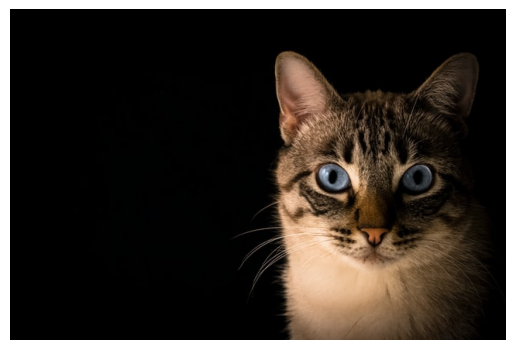

In [ ]:
# Write your code here
import cv2
import matplotlib.pyplot as plt
image = cv2.imread("cat.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

## 2. Drawing and Text
**Task:**
1. Create a blank image of size $500 \times 500$ with 3 color channels.
2. Paint a portion of the image red ($[200:300, 300:400]$).
3. Draw a green rectangle from $(0,0)$ to the center of the image.
4. Draw a red circle at the center with a radius of 40.
5. Draw a white line from $(100, 250)$ to $(300, 400)$.



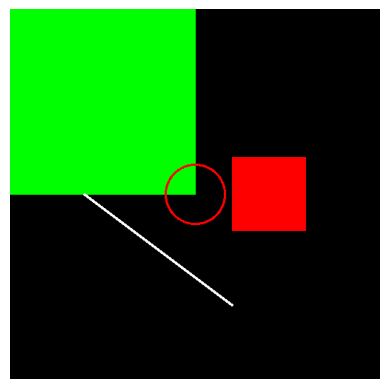

In [34]:
# Write your code here
import cv2
import matplotlib.pyplot as plt
import numpy as np
image = np.zeros((500, 500, 3), dtype=np.uint8)
image[200:300, 300:400] = (0, 0, 255) 
cv2.rectangle(image, (0, 0), (250, 250), (0, 255, 0), -1)
cv2.circle(image, (250, 250), 40, (0, 0, 255), 2)
cv2.line(image, (100, 250), (300, 400), (255, 255, 255), 2)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

## 3. Basic Image Functions
**Task:**
1. Load `park.jpg`.
2. Convert it to grayscale.
3. Apply Gaussian Blur with a $(7,7)$ kernel.
4. Perform Canny Edge detection on the blurred image.


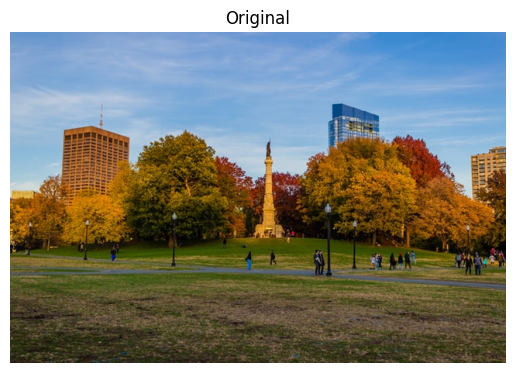

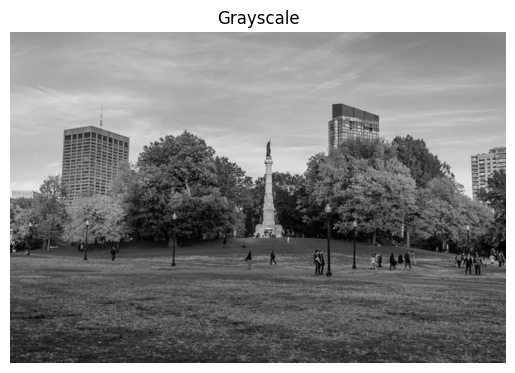

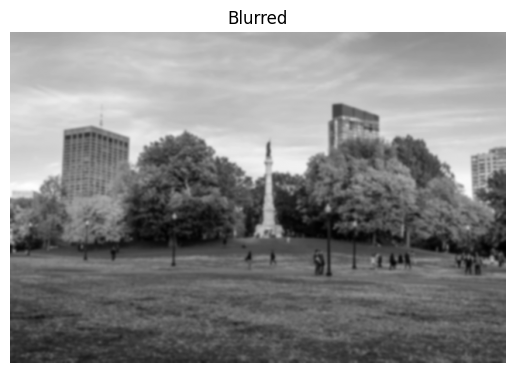

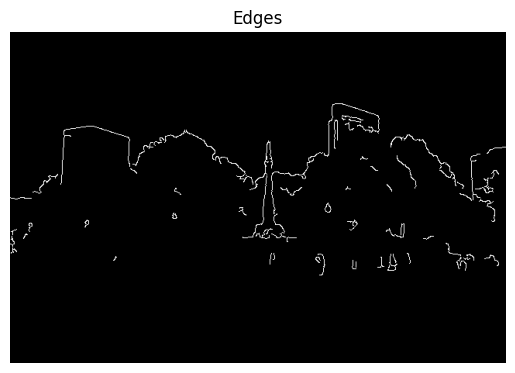

In [1]:
# Write your code here
import cv2
import matplotlib.pyplot as plt
image = cv2.imread("park.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (7, 7), 0)
edges = cv2.Canny(blurred, 100, 200)
titles = ["Original", "Grayscale", "Blurred", "Edges"]
images = [cv2.cvtColor(image, cv2.COLOR_BGR2RGB), gray, blurred, edges]

for i in range(4):
    plt.figure()
    plt.imshow(images[i], cmap="gray" if i > 0 else None)
    plt.title(titles[i])
    plt.axis("off")

plt.show()

## 4. Image Transformations
**Task:**
1. Create a function `translate(img, x, y)` to shift an image.
2. Create a function `rotate(img, angle, rotPoint=None)` to rotate an image.
3. Apply a flip transformation to `park.jpg`.

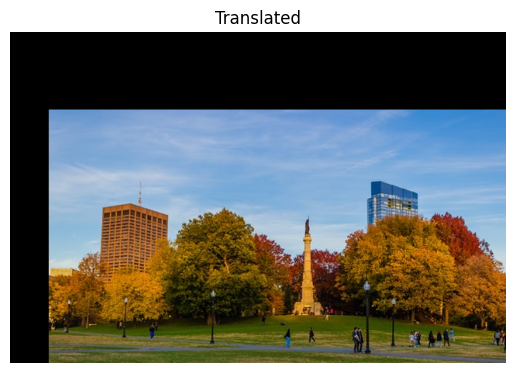

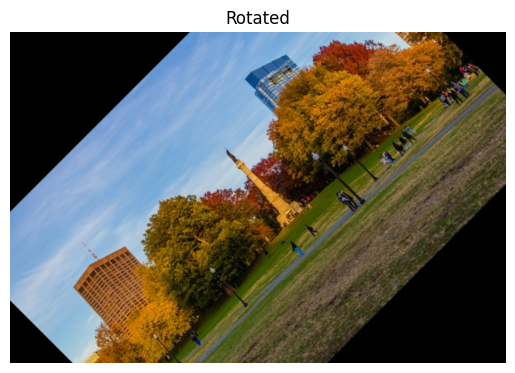

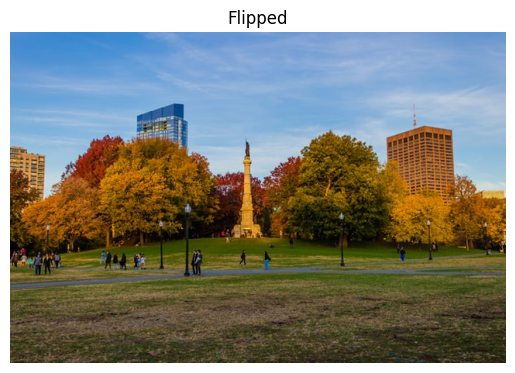

In [ ]:
# Write your code here
import cv2
import matplotlib.pyplot as plt
import numpy as np
image = cv2.imread("park.jpg")
def translate(img, x, y):
    matrix = np.float32([[1, 0, x],
                         [0, 1, y]])
    return cv2.warpAffine(img, matrix, (img.shape[1], img.shape[0]))

def rotate(img, angle, rotPoint=None):
    h, w = img.shape[:2]
    if rotPoint is None:
        rotPoint = (w // 2, h // 2)
    matrix = cv2.getRotationMatrix2D(rotPoint, angle, 1.0)
    return cv2.warpAffine(img, matrix, (w, h))

flipped = cv2.flip(image, 1)
translated = translate(image, 50, 100)
rotated = rotate(image, 45)
titles = ["Translated", "Rotated", "Flipped"]
imgs = [translated, rotated, flipped]
for i in range(3):
    plt.figure()
    plt.imshow(cv2.cvtColor(imgs[i], cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis("off")

plt.show()

## 5. Contour Detection
**Task:**
1. Load `cats.jpg`.
2. Convert to grayscale and apply Gaussian blur.
3. Find the edges using Canny.
4. Use `cv.findContours` to find all contours.
5. Print the count and draw them on a blank image.

Total contours found: 88


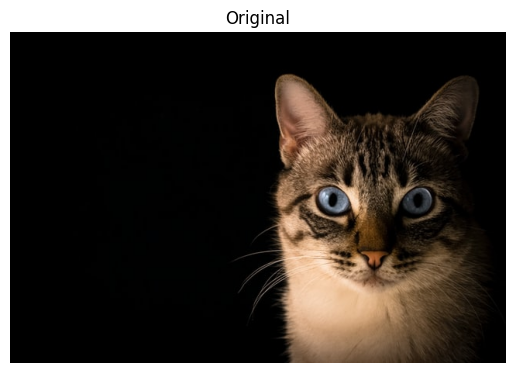

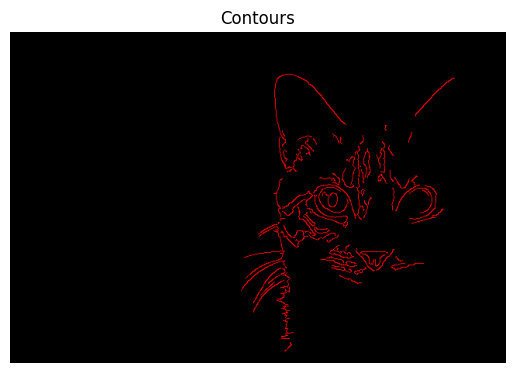

In [22]:
# Write your code here
import cv2
import matplotlib.pyplot as plt
image = cv2.imread("cat.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 100, 200)
contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Total contours found: {len(contours)}")
blank = np.zeros_like(image) 
cv2.drawContours(blank, contours, -1, (0,0,255), 1)
plt.figure()
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")
plt.show()

plt.figure()
plt.imshow(cv2.cvtColor(blank, cv2.COLOR_BGR2RGB))
plt.title("Contours")
plt.axis("off")
plt.show()



## 6. Color Spaces
**Task:**
1. Load `park.jpg`.
2. Convert and display in: Gray, HSV,and RGB.

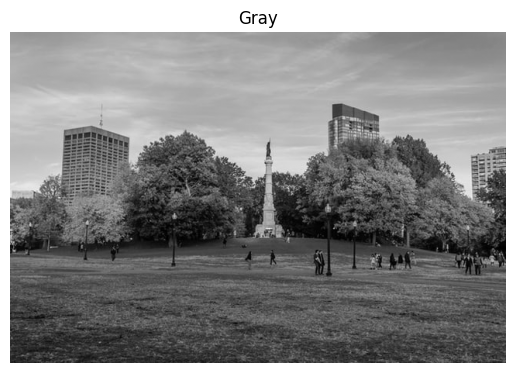

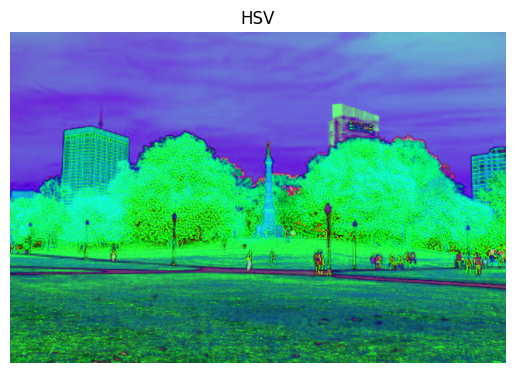

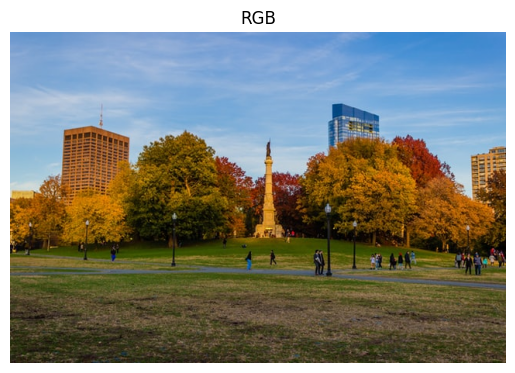

In [ ]:
# Write your code here
import cv2
import matplotlib.pyplot as plt
image = cv2.imread("park.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
hsv  = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
rgb  = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
titles = ["Gray", "HSV", "RGB"]
images = [gray, hsv, rgb]
cmaps  = ["gray", None, None]

for i in range(3):
    plt.figure()
    plt.imshow(images[i], cmap=cmaps[i])
    plt.title(titles[i])
    plt.axis("off")

plt.show()

## 7. Smoothing and Blurring
**Task:**
1. Load `cats.jpg`.
2. Apply Averaging, Gaussian and Median Blurs

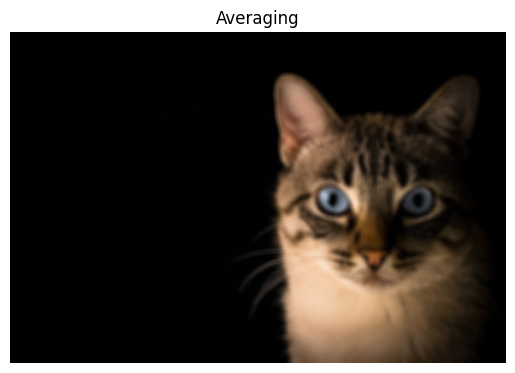

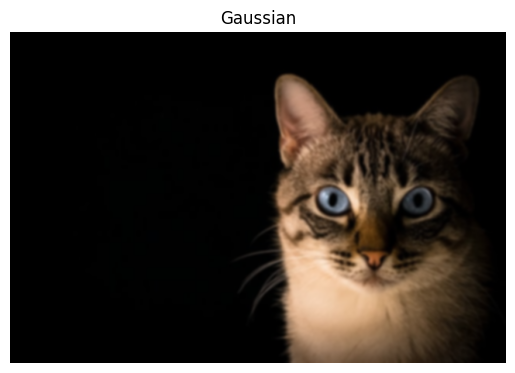

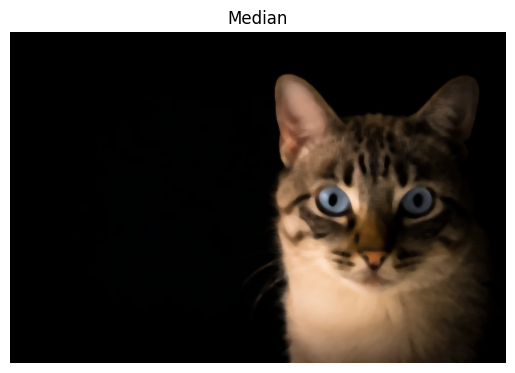

In [ ]:
# Write your code here
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("cat.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
average = cv2.blur(image, (7, 7))
gaussian = cv2.GaussianBlur(image, (7, 7), 0)
median = cv2.medianBlur(image, 7)
titles = ["Averaging", "Gaussian", "Median"]
images = [cv2.cvtColor(average, cv2.COLOR_BGR2RGB),
          cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB),
          cv2.cvtColor(median,  cv2.COLOR_BGR2RGB)]

for i in range(3):
    plt.figure()
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.show()

## 8. Bitwise Operations
**Task:**
1. Create a $400 \times 400$ blank image.
2. Create a rectangle and a circle on separate blank images.
3. Perform Bitwise AND, OR, XOR, and NOT.

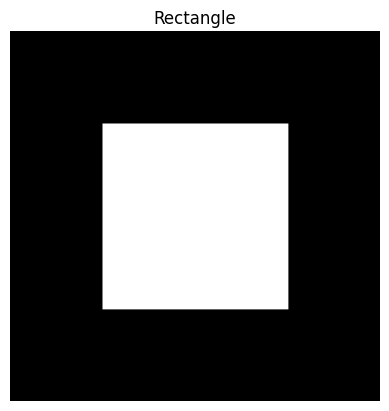

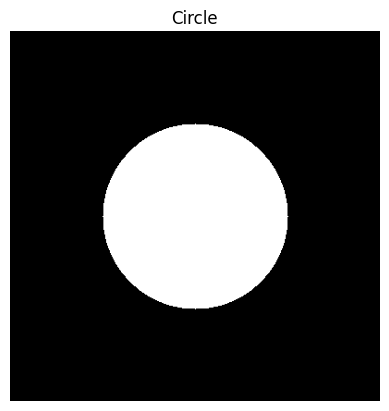

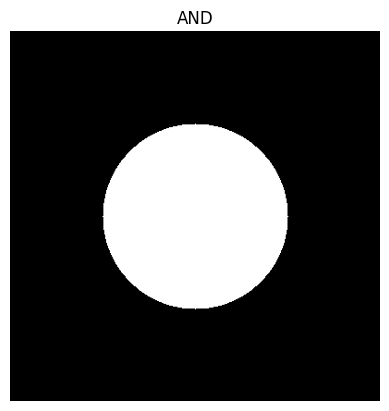

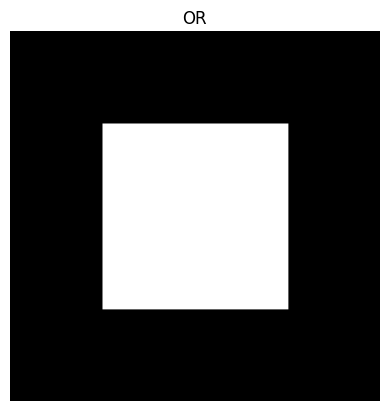

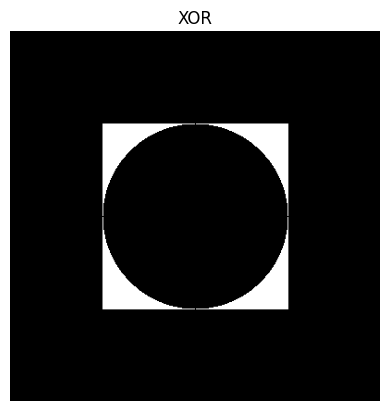

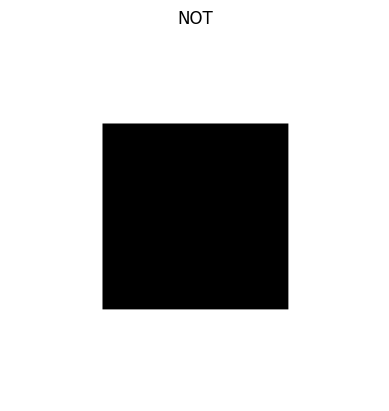

In [ ]:
# Write your code here
import cv2
import numpy as np
import matplotlib.pyplot as plt
img1 = np.zeros((400, 400), dtype=np.uint8)
img2 = np.zeros((400, 400), dtype=np.uint8)
cv2.rectangle(img1, (100, 100), (300, 300), 255, -1)
cv2.circle(img2, (200, 200), 100, 255, -1)
AND = cv2.bitwise_and(img1, img2)
OR  = cv2.bitwise_or(img1, img2)
XOR = cv2.bitwise_xor(img1, img2)
NOT = cv2.bitwise_not(img1)
titles = ["Rectangle", "Circle", "AND", "OR", "XOR", "NOT"]
images = [img1, img2, AND, OR, XOR, NOT]

for i in range(6):
    plt.figure()
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.show()

## 9. Thresholding
**Task:**
1. Load `cats.jpg` and convert to grayscale.
2. Apply Simple Thresholding (Binary and Inverse).

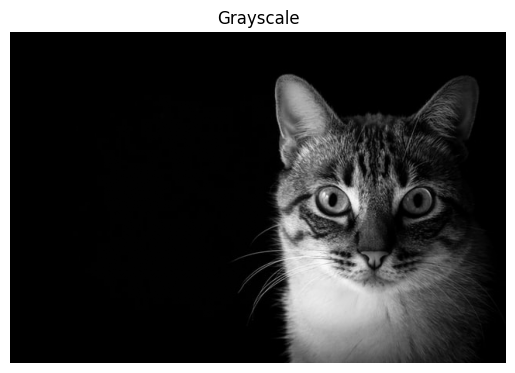

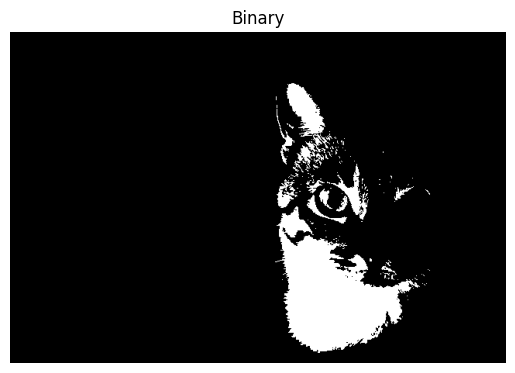

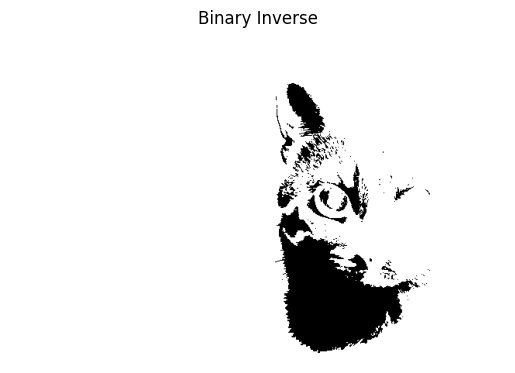

In [31]:
# Write your code here
import cv2
import matplotlib.pyplot as plt
image = cv2.imread("cat.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Binary — pixels above 127 become white (255), below become black (0)
ret, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
ret, binary_inv = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
titles = ["Grayscale", "Binary", "Binary Inverse"]
images = [gray, binary, binary_inv]

for i in range(3):
    plt.figure()
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.show()